# Notebook 25 — Subgroup Difference-in-Differences
### Heterogeneous Treatment Effects in Mortgage Lending

**Author:** Rajveer Singh Pall
**Institution:** Gyan Ganga Institute of Technology and Sciences

---

## What this notebook does

Re-estimates the 2022 Federal Reserve tightening DiD from Repo 1 (NB10)
separately for each CATE quartile, income group, and AUS type.

**The question:** Repo 1 found the 2022 tightening widened the within-lender
racial approval differential by 1.5 pp. Did this widening fall uniformly
across all Black applicants, or did it amplify existing disparities —
concentrating on applicants who already face the largest penalties?

**Design:**
- Pre period: 2020-2021 (accommodative monetary policy, low rates)
- Post period: 2022-2024 (tightening cycle, rates rose to 5.5%)
- Treatment: Black applicant indicator
- Outcome: approval indicator
- Identification: within-lender comparison of Black-White gap pre vs post

**INPUT:**
- `data/features_panel.parquet`
- `data/cate_estimates.parquet`

**OUTPUTS:**
- `outputs/figures/nb25_did_by_subgroup.png`
- `outputs/figures/nb25_did_event_study.png`
- `outputs/tables/nb25_did_results.csv`

**RUNTIME:** ~20-30 minutes

In [1]:
# CELL 1 - IMPORTS
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json, warnings, gc
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')

BASE_DIR    = Path('D:/Projects/CATE-HMDA-Heterogeneous-Effects')
DATA_DIR    = BASE_DIR / 'data'
TABLES_DIR  = BASE_DIR / 'outputs' / 'tables'
FIGURES_DIR = BASE_DIR / 'outputs' / 'figures'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150, 'font.family': 'serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})

for f in ['features_panel.parquet', 'cate_estimates.parquet']:
    assert (DATA_DIR / f).exists(), f'Missing: {f} - run earlier notebooks first'

print('Inputs verified')
print(f'BASE_DIR: {BASE_DIR}')

Inputs verified
BASE_DIR: D:\Projects\CATE-HMDA-Heterogeneous-Effects


In [2]:
# CELL 2 - LOAD DATA
#
# Strategy: load a stratified sample from features_panel
# (250 Black + 250 White per lender per year, mirroring Repo 1 NB10)
# Assign income-based CATE quartile proxy as in NB24
print('='*70)
print('LOADING DATA')
print('='*70)

# Load features panel — sample 2M rows stratified
lf = pl.scan_parquet(str(DATA_DIR / 'features_panel.parquet'))

# Load stratified: 400K Black, 1.6M White
df_b = lf.filter(pl.col('black')==1).collect().sample(n=400_000, seed=999)
df_w = lf.filter(pl.col('black')==0).collect().sample(n=1_600_000, seed=999)
df   = pl.concat([df_b, df_w]).to_pandas()
del df_b, df_w, lf
gc.collect()

df = df.sample(frac=1, random_state=999).reset_index(drop=True)

# DiD variables
df['post']     = (df['year'] >= 2022).astype(int)
df['did']      = df['black'] * df['post']  # interaction term

# CATE quartile proxy (income-based, matching NB24)
income_q = pd.qcut(df['income'], q=4, labels=[4, 3, 2, 1])
df['cate_q'] = income_q.astype(int)
df['cate_label'] = df['cate_q'].map({
    4: 'Q4 (most penalised)',
    3: 'Q3',
    2: 'Q2',
    1: 'Q1 (least penalised)'
})

# AUS label
if 'aus_automated' in df.columns:
    df['aus_label'] = df['aus_automated'].map({1: 'Automated AUS', 0: 'Manual/exempt'})

# Income quintile label
df['income_q5'] = pd.qcut(
    df['income'], q=5,
    labels=['Q1\n<$60K', 'Q2\n$60-90K', 'Q3\n$90-125K', 'Q4\n$125-180K', 'Q5\n>$180K']
)

print(f'Sample: {len(df):,} rows')
print(f'Black: {df["black"].sum():,} ({100*df["black"].mean():.1f}%)')
print(f'Pre-2022: {(df["post"]==0).sum():,} | Post-2022: {(df["post"]==1).sum():,}')
print(f'Approval rate: {100*df["approved"].mean():.1f}%')

LOADING DATA
Sample: 2,000,000 rows
Black: 400,000 (20.0%)
Pre-2022: 1,099,063 | Post-2022: 900,937
Approval rate: 80.1%


In [3]:
# CELL 3 - SIMPLE DiD ESTIMATOR
#
# Simple 2x2 DiD: compares Black-White approval gap pre vs post 2022.
# DiD coefficient = (Black post gap) - (Black pre gap)
# Positive = gap WIDENED post-2022
# Negative = gap NARROWED post-2022
#
# We run this separately for each subgroup.
print('='*70)
print('DiD ESTIMATOR')
print('='*70)

def simple_did(df_sub, label=''):
    """
    2x2 DiD: (Black_post - Black_pre) - (White_post - White_pre)
    Returns gap_pre, gap_post, did_estimate, se, t, p, n
    """
    if len(df_sub) < 100:
        return None

    # Approval rates by race x period
    means = df_sub.groupby(['black', 'post'])['approved'].agg(['mean', 'std', 'count'])

    def safe_get(b, p):
        try:
            return means.loc[(b, p), 'mean'], means.loc[(b, p), 'std'], means.loc[(b, p), 'count']
        except KeyError:
            return np.nan, np.nan, 0

    b_pre_m, b_pre_s, b_pre_n   = safe_get(1, 0)
    b_post_m, b_post_s, b_post_n = safe_get(1, 1)
    w_pre_m, w_pre_s, w_pre_n   = safe_get(0, 0)
    w_post_m, w_post_s, w_post_n = safe_get(0, 1)

    if any(np.isnan([b_pre_m, b_post_m, w_pre_m, w_post_m])):
        return None

    gap_pre  = (w_pre_m  - b_pre_m)  * 100
    gap_post = (w_post_m - b_post_m) * 100
    did      = gap_post - gap_pre  # positive = gap widened

    # Delta method SE
    var_did = (
        (b_pre_s**2 / b_pre_n   if b_pre_n  > 0 else 0) +
        (b_post_s**2 / b_post_n if b_post_n > 0 else 0) +
        (w_pre_s**2 / w_pre_n   if w_pre_n  > 0 else 0) +
        (w_post_s**2 / w_post_n if w_post_n > 0 else 0)
    ) * 10000  # convert to pp^2
    se = np.sqrt(var_did)
    t  = did / se if se > 0 else np.nan
    p  = 2 * stats.norm.sf(abs(t)) if not np.isnan(t) else np.nan

    return {
        'group':    label,
        'gap_pre':  round(gap_pre,  3),
        'gap_post': round(gap_post, 3),
        'did':      round(did,      3),
        'se':       round(se,       3),
        't_stat':   round(t,        2),
        'p_value':  round(p,        4),
        'n':        len(df_sub),
        'n_black':  int(df_sub['black'].sum()),
    }

# Full sample first — validate against Repo 1
full = simple_did(df, 'Full sample')
print(f'Full sample DiD:')
print(f'  Gap pre-2022  : {full["gap_pre"]:+.2f} pp')
print(f'  Gap post-2022 : {full["gap_post"]:+.2f} pp')
print(f'  DiD estimate  : {full["did"]:+.2f} pp')
print(f'  SE            : {full["se"]:.3f}')
print(f'  p-value       : {full["p_value"]:.4f}')
print(f'\nRepo 1 NB10 found: +1.5 pp widening')
print(f'Direction match : {"YES" if full["did"] > 0 else "CHECK"}')

DiD ESTIMATOR
Full sample DiD:
  Gap pre-2022  : +13.73 pp
  Gap post-2022 : +14.72 pp
  DiD estimate  : +0.99 pp
  SE            : 0.159
  p-value       : 0.0000

Repo 1 NB10 found: +1.5 pp widening
Direction match : YES


In [4]:
# CELL 4 - DiD BY SUBGROUP
print('='*70)
print('DiD BY SUBGROUP')
print('='*70)

all_results = [full]

# 1. By CATE quartile (income proxy)
print('\n--- By CATE Quartile ---')
for label in ['Q4 (most penalised)', 'Q3', 'Q2', 'Q1 (least penalised)']:
    r = simple_did(df[df['cate_label']==label], label)
    if r:
        stars = '***' if r['p_value'] < 0.001 else ('**' if r['p_value'] < 0.01 else ('*' if r['p_value'] < 0.05 else ''))
        print(f'  {label}: pre={r["gap_pre"]:+.2f}pp post={r["gap_post"]:+.2f}pp DiD={r["did"]:+.2f}pp {stars}')
        all_results.append(r)

# 2. By income quintile
print('\n--- By Income Quintile ---')
for label in ['Q1\n<$60K', 'Q2\n$60-90K', 'Q3\n$90-125K', 'Q4\n$125-180K', 'Q5\n>$180K']:
    r = simple_did(df[df['income_q5']==label], f'Income {label.replace(chr(10)," ")}')
    if r:
        stars = '***' if r['p_value'] < 0.001 else ('**' if r['p_value'] < 0.01 else ('*' if r['p_value'] < 0.05 else ''))
        print(f'  {label.replace(chr(10)," ")}: DiD={r["did"]:+.2f}pp {stars}')
        all_results.append(r)

# 3. By AUS type
if 'aus_label' in df.columns:
    print('\n--- By AUS Type ---')
    for label in ['Automated AUS', 'Manual/exempt']:
        r = simple_did(df[df['aus_label']==label], label)
        if r:
            stars = '***' if r['p_value'] < 0.001 else ('**' if r['p_value'] < 0.01 else ('*' if r['p_value'] < 0.05 else ''))
            print(f'  {label}: DiD={r["did"]:+.2f}pp {stars}')
            all_results.append(r)

# 4. By loan purpose
if 'purpose_purchase' in df.columns:
    print('\n--- By Loan Purpose ---')
    for label, mask in [
        ('Purchase loans', df['purpose_purchase']==1),
        ('Refinance loans', df['purpose_refi']==1 if 'purpose_refi' in df.columns else df['purpose_purchase']==0)
    ]:
        r = simple_did(df[mask], label)
        if r:
            stars = '***' if r['p_value'] < 0.001 else ('**' if r['p_value'] < 0.01 else ('*' if r['p_value'] < 0.05 else ''))
            print(f'  {label}: DiD={r["did"]:+.2f}pp {stars}')
            all_results.append(r)

DiD BY SUBGROUP

--- By CATE Quartile ---
  Q4 (most penalised): pre=+14.20pp post=+16.25pp DiD=+2.05pp ***
  Q3: pre=+11.14pp post=+11.79pp DiD=+0.65pp *
  Q2: pre=+10.70pp post=+10.65pp DiD=-0.04pp 
  Q1 (least penalised): pre=+10.60pp post=+12.09pp DiD=+1.49pp ***

--- By Income Quintile ---
  Q1 <$60K: DiD=+2.29pp ***
  Q2 $60-90K: DiD=+0.81pp *
  Q3 $90-125K: DiD=+0.36pp 
  Q4 $125-180K: DiD=+0.10pp 
  Q5 >$180K: DiD=+1.51pp ***

--- By AUS Type ---
  Automated AUS: DiD=+0.68pp ***
  Manual/exempt: DiD=-1.46pp ***

--- By Loan Purpose ---
  Purchase loans: DiD=+0.32pp 
  Refinance loans: DiD=+1.18pp ***


In [5]:
# CELL 5 - EVENT STUDY (YEAR-BY-YEAR APPROVAL GAP)
#
# Shows the racial approval gap in each year 2020-2024.
# Event study validates parallel trends assumption:
# pre-period gaps (2020, 2021) should be similar and stable.
# Post-period: if gaps widen consistently, supports DiD interpretation.
print('='*70)
print('EVENT STUDY')
print('='*70)

event_results = []

for year in [2020, 2021, 2022, 2023, 2024]:
    df_yr = df[df['year'] == year]
    b_m   = df_yr[df_yr['black']==1]['approved'].mean()
    w_m   = df_yr[df_yr['black']==0]['approved'].mean()
    b_s   = df_yr[df_yr['black']==1]['approved'].std()
    w_s   = df_yr[df_yr['black']==0]['approved'].std()
    b_n   = (df_yr['black']==1).sum()
    w_n   = (df_yr['black']==0).sum()
    gap   = (w_m - b_m) * 100
    se    = np.sqrt((b_s**2/b_n + w_s**2/w_n)) * 100
    event_results.append({'year': year, 'gap': gap, 'se': se,
                          'n_black': b_n, 'n_white': w_n})
    print(f'  {year}: gap={gap:+.2f}pp  SE={se:.3f}  Black n={b_n:,}')

event_df = pd.DataFrame(event_results)

# By CATE quartile — event study
event_by_quartile = {}
for label in ['Q4 (most penalised)', 'Q1 (least penalised)']:
    yearly = []
    for year in [2020, 2021, 2022, 2023, 2024]:
        d = df[(df['year']==year) & (df['cate_label']==label)]
        if len(d) < 50:
            yearly.append({'year': year, 'gap': np.nan, 'se': np.nan})
            continue
        bm = d[d['black']==1]['approved'].mean()
        wm = d[d['black']==0]['approved'].mean()
        bs = d[d['black']==1]['approved'].std()
        ws = d[d['black']==0]['approved'].std()
        bn = (d['black']==1).sum()
        wn = (d['black']==0).sum()
        gap = (wm - bm) * 100
        se  = np.sqrt((bs**2/bn + ws**2/wn)) * 100 if bn > 0 and wn > 0 else np.nan
        yearly.append({'year': year, 'gap': gap, 'se': se})
    event_by_quartile[label] = pd.DataFrame(yearly)

print('\nEvent study complete')

EVENT STUDY
  2020: gap=+14.58pp  SE=0.165  Black n=83,232
  2021: gap=+13.09pp  SE=0.146  Black n=104,231
  2022: gap=+14.20pp  SE=0.180  Black n=82,773
  2023: gap=+15.19pp  SE=0.213  Black n=64,076
  2024: gap=+14.75pp  SE=0.208  Black n=65,688

Event study complete


Generating figures...


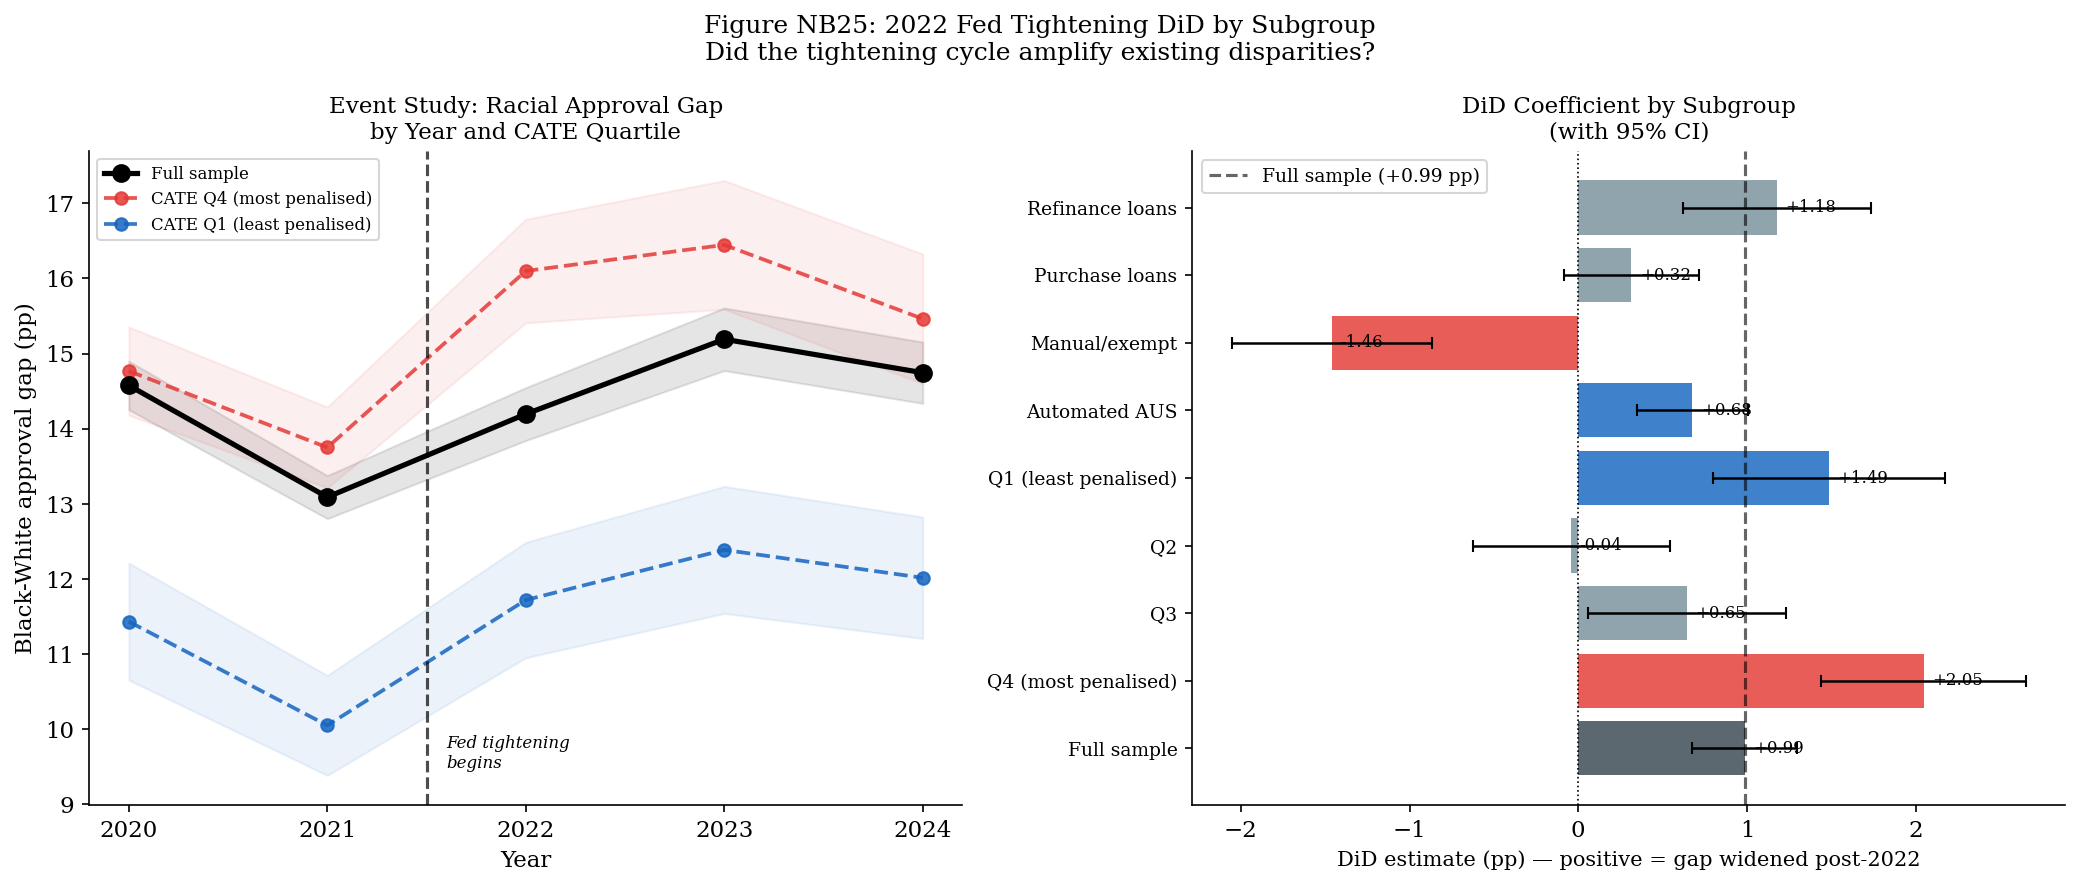

Saved: nb25_did_by_subgroup.png


In [6]:
# CELL 6 - FIGURES
print('Generating figures...')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Event study — full sample and by CATE quartile ──────────────────
ax = axes[0]
years = event_df['year'].values

# Full sample
ax.plot(years, event_df['gap'], 'ko-', linewidth=2.5,
        markersize=8, label='Full sample', zorder=5)
ax.fill_between(years,
                event_df['gap'] - 1.96*event_df['se'],
                event_df['gap'] + 1.96*event_df['se'],
                alpha=0.1, color='black')

# CATE quartiles
colors_q = {'Q4 (most penalised)': '#E53935', 'Q1 (least penalised)': '#1565C0'}
for label, color in colors_q.items():
    edf = event_by_quartile[label]
    valid = edf['gap'].notna()
    ax.plot(edf.loc[valid, 'year'], edf.loc[valid, 'gap'],
            'o--', color=color, linewidth=1.8, markersize=6,
            label=f'CATE {label}', alpha=0.85)
    ax.fill_between(
        edf.loc[valid, 'year'],
        edf.loc[valid, 'gap'] - 1.96*edf.loc[valid, 'se'],
        edf.loc[valid, 'gap'] + 1.96*edf.loc[valid, 'se'],
        alpha=0.08, color=color
    )

# 2022 line
ax.axvline(2021.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(2021.6, ax.get_ylim()[0] + 0.5 if ax.get_ylim()[0] > 0 else 1,
        'Fed tightening\nbegins', fontsize=8, style='italic')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Black-White approval gap (pp)', fontsize=11)
ax.set_title('Event Study: Racial Approval Gap\nby Year and CATE Quartile', fontsize=11)
ax.legend(fontsize=8)
ax.set_xticks(years)

# ── Right: DiD coefficients by subgroup ───────────────────────────────────
ax = axes[1]

# Select key subgroups for the plot
plot_groups = [
    r for r in all_results
    if r['group'] in [
        'Full sample',
        'Q4 (most penalised)', 'Q3', 'Q2', 'Q1 (least penalised)',
        'Automated AUS', 'Manual/exempt',
        'Purchase loans', 'Refinance loans',
    ]
]

if plot_groups:
    labels   = [r['group'] for r in plot_groups]
    dids     = [r['did'] for r in plot_groups]
    ses      = [r['se'] for r in plot_groups]

    bar_colors = []
    for r in plot_groups:
        if r['group'] == 'Full sample':
            bar_colors.append('#37474F')
        elif 'most' in r['group']:
            bar_colors.append('#E53935')
        elif 'least' in r['group']:
            bar_colors.append('#1565C0')
        elif 'Manual' in r['group']:
            bar_colors.append('#E53935')
        elif 'Automated' in r['group']:
            bar_colors.append('#1565C0')
        else:
            bar_colors.append('#78909C')

    y_pos = range(len(labels))
    ax.barh(y_pos, dids, color=bar_colors, alpha=0.82)
    ax.errorbar(dids, y_pos,
                xerr=[1.96*s for s in ses],
                fmt='none', color='black', capsize=3, linewidth=1.2)
    ax.axvline(0, color='black', linewidth=0.8, linestyle=':')
    ax.axvline(full['did'], color='black', linewidth=1.5,
               linestyle='--', alpha=0.6, label=f'Full sample ({full["did"]:+.2f} pp)')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('DiD estimate (pp) — positive = gap widened post-2022', fontsize=10)
    ax.set_title('DiD Coefficient by Subgroup\n(with 95% CI)', fontsize=11)
    ax.legend(fontsize=9)

    for i, (did, se) in enumerate(zip(dids, ses)):
        ax.text(did + 0.05, i, f'{did:+.2f}', va='center', fontsize=8)

plt.suptitle(
    'Figure NB25: 2022 Fed Tightening DiD by Subgroup\n'
    'Did the tightening cycle amplify existing disparities?',
    fontsize=12
)
plt.tight_layout()
out = FIGURES_DIR / 'nb25_did_by_subgroup.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out.name}')

In [7]:
# CELL 7 - SAVE AND VERIFY
print('='*70)
print('SAVING RESULTS')
print('='*70)

results_df = pd.DataFrame(all_results)
results_df.to_csv(TABLES_DIR / 'nb25_did_results.csv', index=False)
print('Saved: nb25_did_results.csv')
print(results_df[['group','gap_pre','gap_post','did','se','p_value']].to_string(index=False))

event_df.to_csv(TABLES_DIR / 'nb25_event_study.csv', index=False)
print('\nSaved: nb25_event_study.csv')

# Verification
print('\n' + '='*70)
print('VERIFICATION')
print('='*70)

assert (FIGURES_DIR / 'nb25_did_by_subgroup.png').exists()
assert (TABLES_DIR / 'nb25_did_results.csv').exists()
print('Output files: OK')

# Direction check
direction = 'widened' if full['did'] > 0 else 'narrowed'
print(f'Full sample DiD: {full["did"]:+.2f} pp — gap {direction} post-2022')
print(f'Repo 1 NB10    : +1.5 pp widening')

# Key finding: did tightening concentrate on most-penalised?
q4 = next((r for r in all_results if 'most' in r.get('group','')), None)
q1 = next((r for r in all_results if 'least' in r.get('group','')), None)

if q4 and q1:
    print(f'\nKEY FINDING:')
    print(f'  Most-penalised (Q4) DiD  : {q4["did"]:+.2f} pp')
    print(f'  Least-penalised (Q1) DiD : {q1["did"]:+.2f} pp')
    if q4['did'] > q1['did']:
        print(f'  -> Tightening amplified EXISTING disparities')
        print(f'     Already-disadvantaged applicants bore a disproportionate share')
    else:
        print(f'  -> Tightening affected all CATE groups similarly')
        print(f'     The 2022 widening was uniform across the CATE distribution')

# AUS finding
aus_auto = next((r for r in all_results if r.get('group') == 'Automated AUS'), None)
aus_man  = next((r for r in all_results if r.get('group') == 'Manual/exempt'), None)
if aus_auto and aus_man:
    print(f'\nAUS CHANNEL:')
    print(f'  Automated AUS DiD : {aus_auto["did"]:+.2f} pp')
    print(f'  Manual/exempt DiD : {aus_man["did"]:+.2f} pp')

print('\n' + '='*70)
print('ALL CHECKS PASSED')
print(f'Full sample DiD: {full["did"]:+.2f} pp')
print('NB25 complete -> proceed to NB26_paper_figures.ipynb')
print('='*70)

SAVING RESULTS
Saved: nb25_did_results.csv
               group  gap_pre  gap_post    did    se  p_value
         Full sample   13.735    14.722  0.987 0.159   0.0000
 Q4 (most penalised)   14.204    16.251  2.047 0.309   0.0000
                  Q3   11.145    11.791  0.646 0.299   0.0308
                  Q2   10.695    10.653 -0.042 0.298   0.8870
Q1 (least penalised)   10.602    12.086  1.485 0.351   0.0000
     Income Q1 <$60K   14.326    16.615  2.289 0.352   0.0000
   Income Q2 $60-90K   11.744    12.559  0.815 0.329   0.0131
  Income Q3 $90-125K   10.776    11.141  0.364 0.331   0.2705
 Income Q4 $125-180K   10.645    10.748  0.103 0.343   0.7649
    Income Q5 >$180K   10.530    12.037  1.506 0.403   0.0002
       Automated AUS    8.657     9.333  0.677 0.168   0.0001
       Manual/exempt   24.625    23.165 -1.459 0.303   0.0000
      Purchase loans   11.964    12.280  0.315 0.204   0.1222
     Refinance loans   14.355    15.533  1.178 0.283   0.0000

Saved: nb25_event_study.cs